In [1]:
import base64
import re
import textwrap
from io import BytesIO
from pathlib import Path
import os

from altair import TOPLEVEL_ONLY_KEYS
from sklearn.externals.array_api_compat.torch import equal
from websockets import InvalidParameterValue

os.environ["HF_HOME"] = r"D:\Workspace\RAG_Integration\SamplePDF\hf_cache"

import numpy as np
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, RapidOcrOptions, PaginatedPipelineOptions, TableStructureOptions, smolvlm_picture_description
from docling.document_converter import DocumentConverter, WordFormatOption, PdfFormatOption
from dotenv import load_dotenv
from IPython.display import HTML, display
from ollama import chat
from PIL import Image
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity

D:\Workspace\RAG_Integration\RAG_System_Unified_Search_Engine\PDF_Extrating\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

False

Convert PDF to Markdown

Document converter can be used for PDF as well as DOCX.

In [107]:
table_structure_option= TableStructureOptions(
    do_cell_matching = True
)
pipeline_option = PdfPipelineOptions (
    generate_page_images=True,
    images_scale=1.00,
    do_ocr=True,
    do_picture_description=True,
    ocr_options=RapidOcrOptions(),
    do_table_structure=True,
    table_structure_options = table_structure_option,
    picture_description_options=smolvlm_picture_description
)

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_option
        ),
        InputFormat.DOCX: WordFormatOption(),   # default options
    }
)
document_path = Path("data/Sample.pdf")
document_path

WindowsPath('data/Sample.pdf')

In [108]:
%%time
result = converter.convert(document_path)
documents = result.document
print(documents.export_to_markdown(page_no=1))


[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.
Loading weights: 100%|██████████| 471/471 [00:00<00:00, 3741.22it/s]
The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
[INFO] 2026-07-09 19:16:19,419 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-09 19:16:19,549 [RapidOCR] download_file.py:60: File exists and is valid: D:\Workspace\RAG_Integration\RAG_System_Unified_Search_Engine\PDF_Extrating\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-07-09 19:16:19,550 [RapidOCR] main.py:63: Using D:\Workspace\RAG_Integration\RAG_System_Unified_Search_Engine\PDF_Extrating\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-07-09 19:16:19,696 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-09 19:16:19,699 [RapidOCR] downl

<!-- image -->

## NVIDIA Announces Financial Results for Fourth Quarter and Fiscal 2025

- Record quarterly revenue of $39.3 billion, up 12% from Q3 and up 78% from a year ago
- Record quarterly Data Center revenue of $35.6 billion, up 16% from Q3 and up 93% from a year ago
- Record full-year revenue of $130.5 billion, up 114%

NVIDIA (NASDAQ: NVDA) today reported revenue for the fourth quarter ended January 26, 2025, of $39.3 billion, up 12% from the previous quarter and up 78% from a year ago.

For the quarter, GAAP earnings per diluted share was $0.89, up 14% from the previous quarter and up 82% from a year ago. Non-GAAP earnings per diluted share was $0.89, up 10% from the previous quarter and up 71% from a year ago.

For fiscal 2025, revenue was $130.5 billion, up 114% from a year ago. GAAP earnings per diluted share was $2.94, up 147% from a year ago. Non-GAAP earnings per diluted share was $2.99, up 130% from a year ago.

'Demand for Blackwell is amazing as reasoning AI adds an

In [126]:
from docling_core.types.doc import DocItemLabel


class MetaData:
    def __init__(self, file_name:str, location:str, page_no:int):
        self.file_name =file_name
        self.location = location
        self.page_no = page_no

    def __str__(self):

        return (f" \"metadata\": "
                f"{{ "
                f"\"document_name\":\"{self.file_name}\", "
                f"\"file_location\":\"{self.location} \" }}")

class DataStructure:
    def __init__(self, obj_type:DocItemLabel, level:int, content:str, meta:MetaData):
        self.level = level
        self.content = content
        self.obj_type = obj_type
        self.meta = meta

    def __str__(self) -> str :

        return (f" {{ "
                f"\"content\":\"{self.content}\", "
                f"{self.meta} }}")



class DataLinkStructure(DataStructure):
    def __init__(self, obj_type:DocItemLabel, level:int, content:str, meta:MetaData):
        super().__init__(obj_type, level, content, meta)
        self._link_data = None
        self._section_data = None

    @property
    def link_data(self):
        return self._link_data

    @link_data.setter
    def link_data(self, link_data:DataStructure = None):
        self._link_data = link_data

    @property
    def section_data(self):
        return self._section_data

    @section_data.setter
    def section_data(self, section_data = None):
        self._section_data = section_data

    def __str__(self):

        sub_section:list = []
        section_data:str
        sub_section_data:str = ''
        section:DataLinkStructure = self._section_data
        while section is not None:
            sub_section.append(section.content)
            section = section._section_data

        if sub_section and len(sub_section) > 0:
            if self.obj_type == DocItemLabel.SECTION_HEADER:
                sub_section.insert(0, self.content)
            section_data = sub_section[-1] # Reteieve the last index which is parent
            del sub_section[-1] # Delete the last index
            sub_section_data = '->'.join(sub_section[::-1]) if sub_section else '' #Reverse the order
        else:
            section_data = self.content if self.obj_type == DocItemLabel.SECTION_HEADER else ''

        return (f" {{ "
                f"\"section\":\"{section_data}\","
                f"\"sub_section\":\"{sub_section_data}\","
                f"\"content\":\"{self.content} \","
                f"\"level\":{self.level},"
                f"\"page\":{self.meta.page_no},"
                f"{self.meta} }}")

class TableObj(DataLinkStructure):
    def __init__(self, obj_type:DocItemLabel, level:int, text:str, meta:MetaData, summary:str):
        super().__init__(obj_type, level, text, meta)
        self.summary = summary



In [133]:
from docling_core.types.doc import SectionHeaderItem


def retrieve_chunk(node, doc_name:str, doc_path:str, obj_type) -> DataLinkStructure:

    if hasattr(node, 'prov') and node.prov:
        meta = MetaData(page_no=node.prov[0].page_no, file_name=doc_name, location=doc_path)
    else:
         meta = MetaData(page_no=0, file_name=doc_name, location=doc_path)

    return DataLinkStructure(obj_type=obj_type, level= node.level if hasattr(node, 'level') else 0, content=node.text, meta=meta)

def retrieve_table_chunk(node, doc_name:str, doc_path:str, obj_type, doc) -> DataLinkStructure:

    if hasattr(node, 'prov') and node.prov:
        meta = MetaData(page_no=node.prov[0].page_no, file_name=doc_name, location=doc_path)
    else:
         meta = MetaData(page_no=0, file_name=doc_name, location=doc_path)

    data_text =  node.export_to_dataframe(doc)
    return DataLinkStructure(obj_type=obj_type, level= node.level if hasattr(node, 'level') else 0, content=data_text, meta=meta)

In [137]:
from typing import cast
from docling_core.types.doc import DocItemLabel
from docling_core.types.doc.document import DoclingDocument, NodeItem

document: DoclingDocument = result.document


header_stack = {}
results = []

print(f"doc name {document_path.name}")
print(f"doc path {document_path.as_posix() }")
node: NodeItem
index: int
current_header_level:int = 0
current_header = None
doc_name = document_path.name
doc_path = document_path.as_posix()



for node, index in  document.iterate_items():

    if node.label == DocItemLabel.SECTION_HEADER :
        current_header = retrieve_chunk(cast(SectionHeaderItem, node), doc_name, doc_path, DocItemLabel.SECTION_HEADER)
        if (current_header.level - len(header_stack)) > 1:
            current_header.level = len(header_stack)

        previous_header_level = current_header_level
        current_header_level = 0 if current_header.level == 0 else current_header.level-1
        parent_header =  header_stack[0 if current_header_level == 0 else current_header_level-1] if header_stack and previous_header_level != current_header_level else None

        current_header.section_data = parent_header
        header_stack[current_header_level] = current_header
        if len(header_stack) > 1:
            for k in list(header_stack):
                if k > current_header_level:
                    del header_stack[k]
        #results.append(current_header)


    elif node.label == DocItemLabel.TEXT:
        text_details = retrieve_chunk(node, doc_name, doc_path, DocItemLabel.TEXT)
        text_details.section_data = current_header
        #print(text_details)
        results.append(text_details)

    elif node.label == DocItemLabel.TABLE:
        table_details = retrieve_table_chunk(node, doc_name, doc_path, DocItemLabel.TABLE, document)
        table_details.section_data = current_header
        #print(table_details)
        results.append(table_details)

    elif node.label == DocItemLabel.LIST_ITEM:
        item_list_details = retrieve_chunk(node, doc_name, doc_path, DocItemLabel.LIST_ITEM)
        item_list_details.section_data = current_header
        print(item_list_details)
        results.append(item_list_details)

for data in results:
    print(f"=============> {data}")




doc name Sample.pdf
doc path data/Sample.pdf
 { "section":"NVIDIA Announces Financial Results for Fourth Quarter and Fiscal 2025","sub_section":"","content":"Record quarterly revenue of $39.3 billion, up 12% from Q3 and up 78% from a year ago ","level":0,"page":1, "metadata": { "document_name":"Sample.pdf", "file_location":"data/Sample.pdf " } }
 { "section":"NVIDIA Announces Financial Results for Fourth Quarter and Fiscal 2025","sub_section":"","content":"Record quarterly Data Center revenue of $35.6 billion, up 16% from Q3 and up 93% from a year ago ","level":0,"page":1, "metadata": { "document_name":"Sample.pdf", "file_location":"data/Sample.pdf " } }
 { "section":"NVIDIA Announces Financial Results for Fourth Quarter and Fiscal 2025","sub_section":"","content":"Record full-year revenue of $130.5 billion, up 114% ","level":0,"page":1, "metadata": { "document_name":"Sample.pdf", "file_location":"data/Sample.pdf " } }
 { "section":"Outlook","sub_section":"","content":"Revenue is expec

Check the blox plot


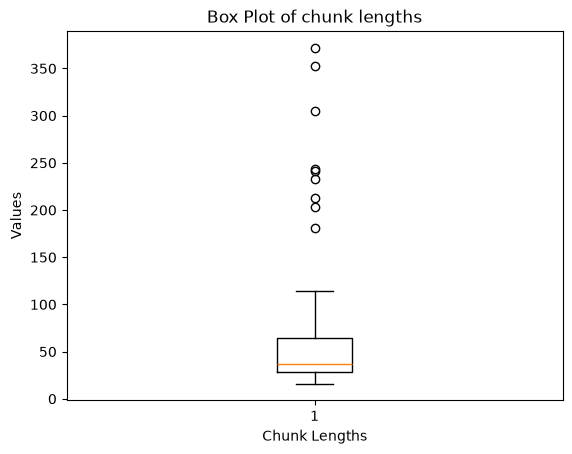

The median chunk lenght is : 37.0
The average chunk lenght is : 69.69
The minimum chunk lenght is : 16
The max chunk lenght is : 372
The 75th percentile chunk length is : 64.0
The 25th percentile chunk length is : 28.25


In [140]:
import matplotlib.pyplot as plt
import numpy as np
data = [len(doc.__str__().split()) for doc in results]

plt.boxplot(data)
plt.title('Box Plot of chunk lengths')  # Title
plt.xlabel('Chunk Lengths')  # Label for x-axis
plt.ylabel('Values')  # Label for y-axis

plt.show()

print(f"The median chunk lenght is : {round(np.median(data),2)}")
print(f"The average chunk lenght is : {round(np.mean(data),2)}")
print(f"The minimum chunk lenght is : {round(np.min(data),2)}")
print(f"The max chunk lenght is : {round(np.max(data),2)}")
print(f"The 75th percentile chunk length is : {round(np.percentile(data, 75),2)}")
print(f"The 25th percentile chunk length is : {round(np.percentile(data, 25),2)}")

In [143]:
data = [ doc if len(doc.__str__().split()) > 200 else None for doc in results]

for d in data:
    if d and d.obj_type != DocItemLabel.TABLE:
        print(d)


 { "section":"Non-GAAP Measures","sub_section":"","content":"To supplement NVIDIA's condensed consolidated financial statements presented in accordance with GAAP, the company uses non-GAAP measures of certain components of financial performance. These non-GAAP measures include non-GAAP gross profit, non-GAAP gross margin, non-GAAP operating expenses, non-GAAP operating income, non-GAAP other income (expense), net, non-GAAP net income, non-GAAP net income, or earnings, per diluted share, and free cash flow. For NVIDIA's investors to be better able to compare its current results with those of previous periods, the company has shown a reconciliation of GAAP to non-GAAP financial measures. These reconciliations adjust the related GAAP financial measures to exclude stock-based compensation expense, acquisition-related and other costs, other, gains from non-marketable and publicly-held equity securities, net, interest expense related to amortization of debt discount, and the associated tax i